# Evalucion

## Metricas, comparacion de modelos y analisis de residuales 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)

preds = pd.read_csv('../results/predicciones.csv', index_col=0, parse_dates=True)
serie_completa = pd.read_csv('../data/serie_semanal.csv', index_col=0, parse_dates=True)['elo_max']

MODELOS = [
    ('SARIMA', 'sarima_pred'),
    ('XGBoost', 'xgb_pred'),
    ('Random Forest', 'rf_pred'),
    ('Gradient Boosting', 'gb_pred'),
]

preds.head()

,real,sarima_pred,xgb_pred,rf_pred,gb_pred
leaderboard_publish_date,,,,,
2026-04-26,1500.255186,1503.084361,1495.9374,1498.101053,1498.288032
2026-05-03,1500.237599,1505.748532,1501.5612,1501.069195,1502.804086
2026-05-10,1500.560585,1508.412703,1500.9896,1501.292646,1502.603523
2026-05-17,1499.640926,1511.076874,1501.2968,1501.270838,1502.640212
2026-05-24,1500.036179,1513.741045,1500.3372,1500.757308,1497.938671


## Serie temporal original (completa)

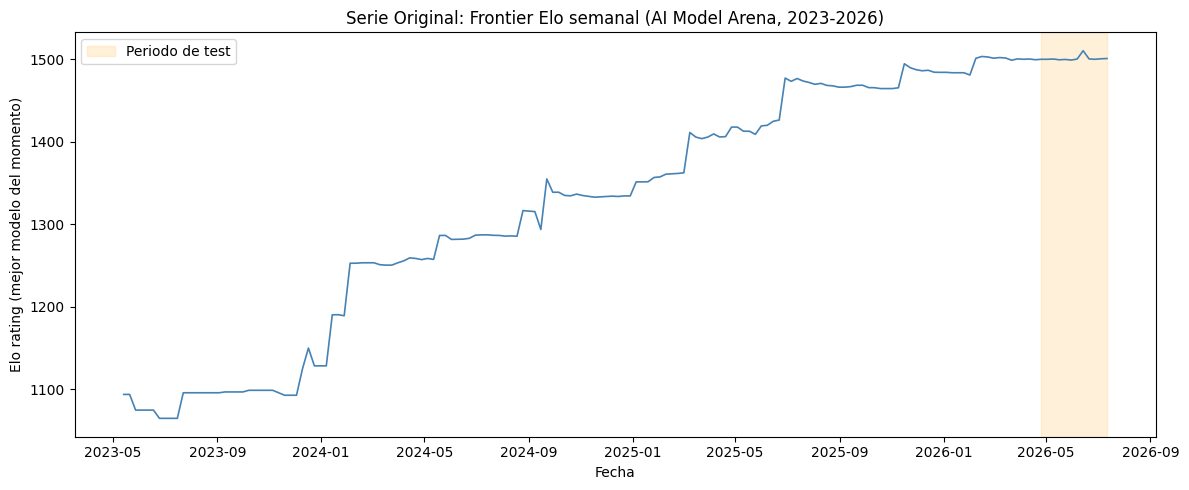

In [2]:
fig, ax = plt.subplots()
ax.plot(serie_completa.index, serie_completa.values, color='steelblue', linewidth=1.2)
ax.set_title('Serie Original: Frontier Elo semanal (AI Model Arena, 2023-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Elo rating (mejor modelo del momento)')
ax.axvspan(preds.index.min(), preds.index.max(), color='orange', alpha=0.15, label='Periodo de test')
ax.legend()
plt.tight_layout()
plt.savefig('../results/graficos_serie_original.png', dpi=120)
plt.show()

# Metricas de evaluacion 

Calculamos RMSE, MAE y MAPE

In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# def smape(y_true, y_pred):
#     return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

# def r2(y_true, y_pred):
#     ss_res = np.sum((y_true - y_pred) ** 2)
#     ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#     if ss_tot == 0:
#         return np.nan  # varianza real nula en el tramo de test: R2 no esta definido
#     return 1 - ss_res / ss_tot

# def mase(y_true, y_pred, y_train, seasonal_period=1):
#     naive_errors = np.abs(np.diff(y_train, n=seasonal_period))
#     scale = np.mean(naive_errors)
#     if scale == 0:
#         return np.nan
#     return np.mean(np.abs(y_true - y_pred)) / scale

serie_train_full = pd.read_csv('../data/serie_semanal.csv', index_col=0, parse_dates=True)['elo_max'].iloc[:-12].values

metricas = []
for modelo, col in MODELOS:
    y_true = preds['real'].values
    y_pred = preds[col].values
    metricas.append({
        'modelo': modelo,
        'RMSE': rmse(y_true, y_pred),
        'MAE': mae(y_true, y_pred),
        'MAPE (%)': mape(y_true, y_pred),
        # 'sMAPE (%)': smape(y_true, y_pred),
        # 'MASE': mase(y_true, y_pred, serie_train_full),
        # 'R2': r2(y_true, y_pred)
    })

df_metricas = pd.DataFrame(metricas).set_index('modelo').round(4)
df_metricas = df_metricas.sort_values('RMSE')
df_metricas.to_csv('../results/metricas.csv')
df_metricas


,RMSE,MAE,MAPE (%)
modelo,,,
Random Forest,3.1556,1.8194,0.1209
XGBoost,3.5819,2.1535,0.1431
Gradient Boosting,4.3368,3.2154,0.2138
SARIMA,18.8569,16.5562,1.1030


### Predicciones vs valores reales

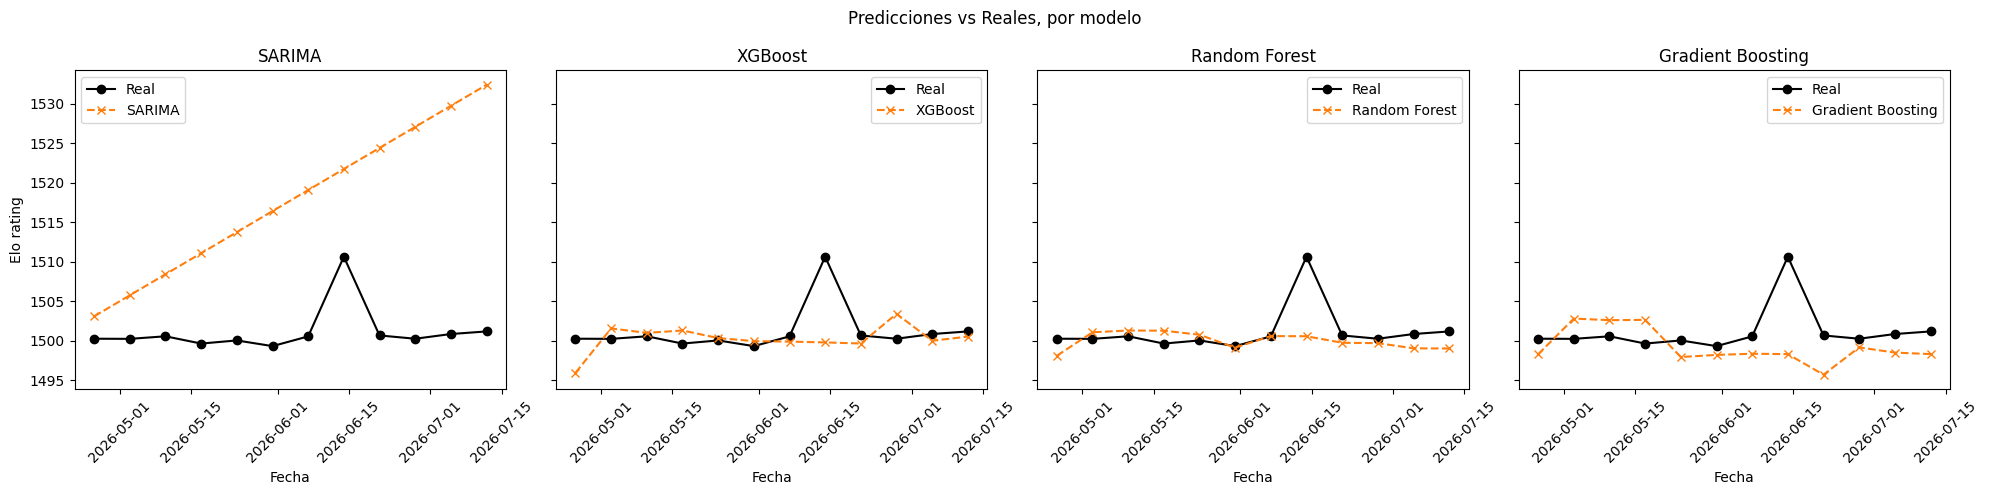

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (modelo, col) in zip(axes, MODELOS):
    ax.plot(preds.index, preds['real'], label='Real', color='black', marker='o')
    ax.plot(preds.index, preds[col], label=modelo, color='tab:orange', linestyle='--', marker='x')
    ax.set_title(f'{modelo}')
    ax.set_xlabel('Fecha')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

axes[0].set_ylabel('Elo rating')
plt.suptitle('Predicciones vs Reales, por modelo')
plt.tight_layout()
plt.savefig('../results/graficos_pred_vs_real.png', dpi=120)
plt.show()


### Comparacion de modelos

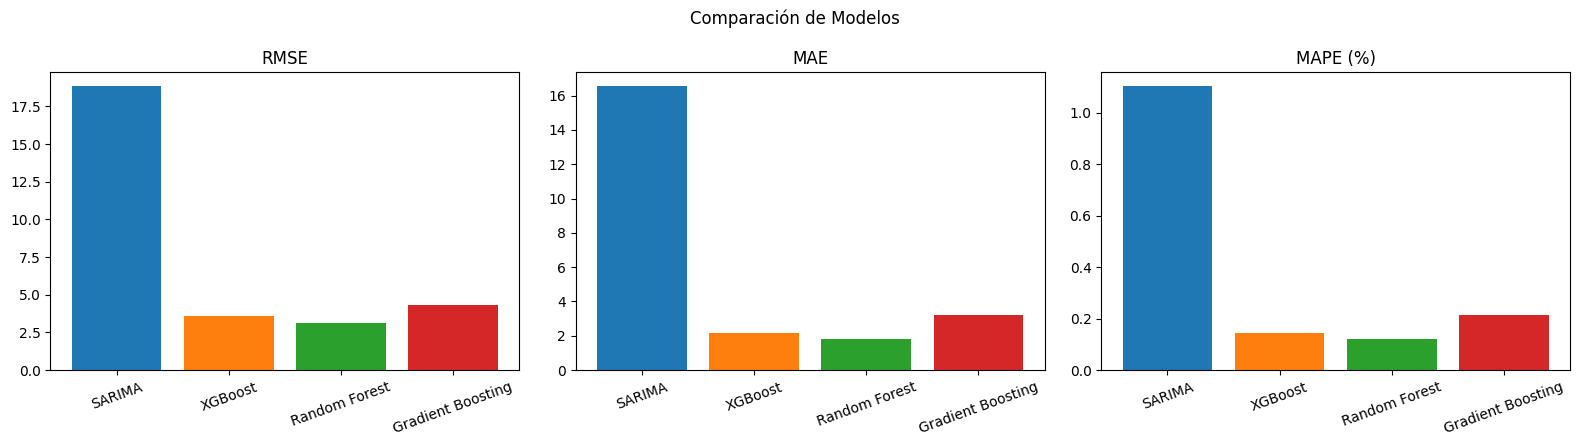

In [5]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE (%)']):
    df_plot = df_metricas.loc[[m for m, _ in MODELOS]]
    ax.bar(df_plot.index, df_plot[metric], color=colors)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Comparación de Modelos')
plt.tight_layout()
plt.savefig('../results/graficos_comparacion_modelos.png', dpi=120)
plt.show()


### Analisis de residuales

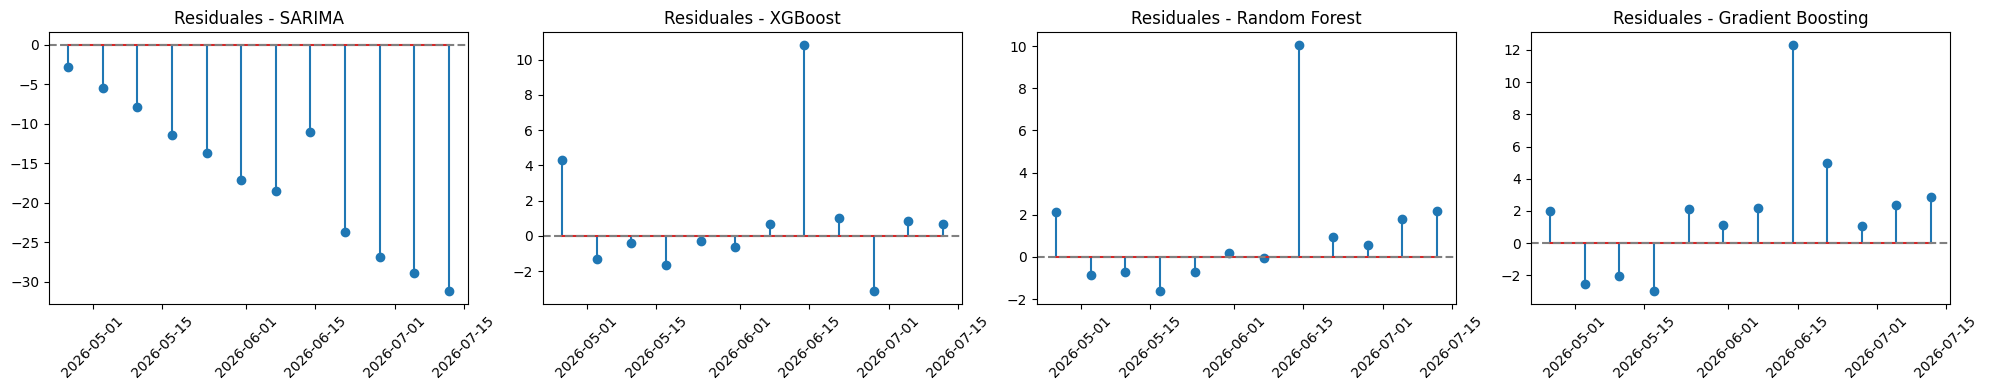

Media de residuales por modelo:
  SARIMA              :  -16.556
  XGBoost             :    0.905
  Random Forest       :    1.160
  Gradient Boosting   :    1.947


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (modelo, col) in zip(axes, MODELOS):
    res = preds['real'] - preds[col]
    ax.stem(preds.index, res)
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_title(f'Residuales - {modelo}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/graficos_residuales.png', dpi=120)
plt.show()

print("Media de residuales por modelo:")
for modelo, col in MODELOS:
    res_mean = (preds['real'] - preds[col]).mean()
    print(f"  {modelo:20s}: {res_mean:8.3f}")

## Conclusiones finales

- **Ranking por RMSE**: los tres modelos de ML (XGBoost, Random Forest, Gradient Boosting) superaron a SARIMA en RMSE, MAE, MAPE, en este horizonte de 12 semanas
- **Diferencias entre los modelos de ML**: Random Forest y Gradient Boosting mostraron predicciones más estables (menor variación semana a semana) que XGBoost, consistente con el efecto de promediado/regularización propio de cada algoritmo de ensamble.
- **Interpretación de dominio**: esto sugiere que, en el corto plazo, el ritmo de mejora de la frontera de capacidad de IA no es perfectamente lineal — hay "mesetas" entre saltos de modelos, algo que un modelo puramente basado en tendencia (SARIMA) no anticipa tan bien como los modelos basados en el comportamiento reciente.
- **Limitaciones**: horizonte de test corto (12 semanas); el forward-fill usado en preprocesamiento genera tramos planos que pueden favorecer artificialmente a modelos "conservadores"; el R2 no es interpretable en este tramo específico por varianza real nula.
- **Trabajo futuro**: probar horizontes de test más largos, LSTM/N-BEATS para capturar mejor los saltos discretos, e incorporar como feature exógena el número de nuevos modelos lanzados por semana.